In [2]:
from utils import (
    compute_ndcg_similarity,
    compute_shap_similarity_pearson,
    compute_score_correlations,
    compute_pred_jaccard,
    plot_heatmaps,
    load_nested_results,
)
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch

In [3]:
all_results = load_nested_results("results/")

In [4]:
all_pearson = []
all_ndcg = []
all_corr_score = []
all_jaccard = []

for dataset_name, results in all_results.items():
    print(dataset_name)

    # Compute all matrices and store them
    pearson_matrix, model_names = compute_shap_similarity_pearson(results)
    ndcg_matrix, _ = compute_ndcg_similarity(results)
    corr_score_matrix, _ = compute_score_correlations(results)
    jaccard_matrix, _ = compute_pred_jaccard(results)

    all_pearson.append(pearson_matrix)
    all_ndcg.append(ndcg_matrix)
    all_corr_score.append(corr_score_matrix)
    all_jaccard.append(jaccard_matrix)

2_annthyroid
4_breastw
14_glass
15_Hepatitis
21_Lymphography
23_mammography
27_PageBlocks
29_Pima
37_Stamps
38_thyroid
39_vertebral
40_vowels
42_WBC
44_Wilt
45_wine
47_yeast


/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_7602/3121868668.py:14: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = sch.linkage(dist_matrix, method="average")


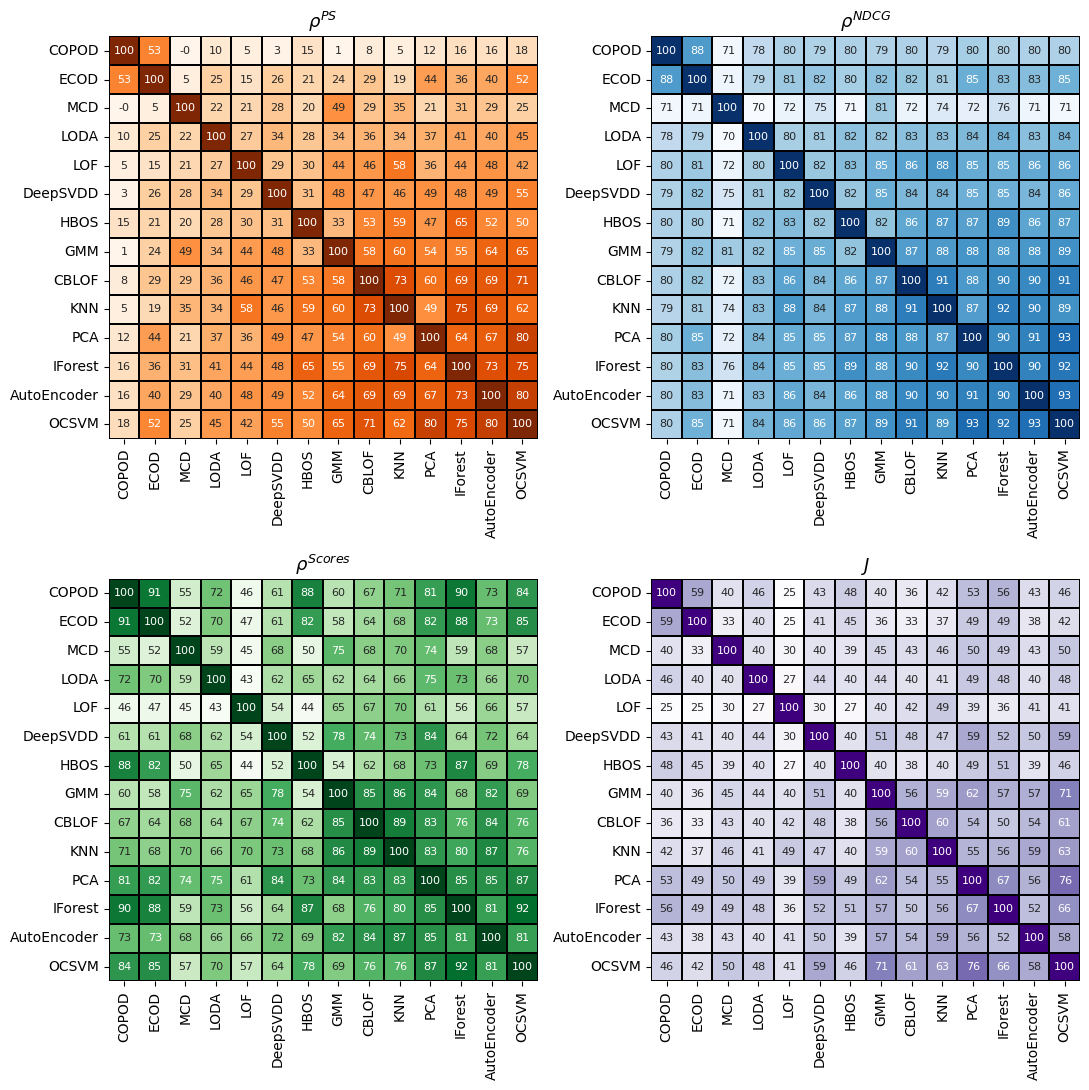

In [23]:
all_matrices = {
    "Pearson SHAP": all_pearson,
    "NDCG SHAP": all_ndcg,
    "Pearson scores": all_corr_score,
    "Jaccard preds": all_jaccard,
}

df_dict = {}
for name, mat_list in all_matrices.items():
    mean_mat = np.nanmean(np.array(mat_list), axis=0)
    df_dict[name] = pd.DataFrame(mean_mat * 100, index=model_names, columns=model_names)

dist_matrix = 100 - df_dict["Pearson SHAP"].values
linkage = sch.linkage(dist_matrix, method="average")
dendro = sch.dendrogram(linkage, no_plot=True)
ordered_labels = [df_dict["Pearson SHAP"].index[i] for i in dendro["leaves"]]

for name in df_dict:
    df_dict[name] = df_dict[name].loc[ordered_labels, ordered_labels]

new_dict = {}
new_dict[r"$\rho^{PS}$"] = df_dict["Pearson SHAP"]
new_dict[r"$\rho^{NDCG}$"] = df_dict["NDCG SHAP"]
new_dict[r"$\rho^{Scores}$"] = df_dict["Pearson scores"]
new_dict[r"$J$"] = df_dict["Jaccard preds"]

fig = plot_heatmaps(
    new_dict,
    figsize=(11, 11),
    colormaps=["Oranges", "Blues", "Greens", "Purples", "Reds", "OrRd"],
)

# fig.savefig("matrices.eps", format="eps", bbox_inches="tight", pad_inches=0.1)

In [45]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

# 1. Fuse the 4 matrices into one Consensus Matrix
# (Assuming all df_dict values are already 0-100 similarities)
# We stack them to 3D and take the mean across the 'matrices' axis
# all_stacked = np.array([df.values for df in df_dict.values()])
# consensus_sim = np.mean(all_stacked, axis=0)

# 2. Convert to Distance Matrix for Clustering
# Distance = Max_Similarity - Similarity
consensus_dist = 100 - np.mean(all_pearson, axis=0)

# Ensure the diagonal is 0 (floating point errors can make it 1e-15)
np.fill_diagonal(consensus_dist, 0)

# Condensed distance matrix is required for some linkage implementations
condensed_dist = squareform(consensus_dist)

# 3. Scientific Clustering (Ward's method is usually best for finding 'clumps')
linkage_consensus = sch.linkage(condensed_dist, method="ward")

# 4. Extract Families (The "Cut")
# We cut the dendrogram to define distinct groups.
# 't' is the max distance to keep points in the same cluster.
# Since our max distance is 100, t=30 means "groups that are at least 70% similar on average"
from scipy.cluster.hierarchy import fcluster

k = 5  # <--- ADJUST THIS THRESHOLD to control how many families you get
family_labels = fcluster(linkage_consensus, t=k, criterion="maxclust")

# Create a mapping of Model Name -> Family ID
families = pd.Series(family_labels, index=model_names, name="Family_ID")
print(families.sort_values())

# 5. Reorder your plot based on this NEW consensus
dendro_consensus = sch.dendrogram(linkage_consensus, no_plot=True)
consensus_order = [model_names[i] for i in dendro_consensus["leaves"]]

# Reorder all your dataframes to this new "Master Order"
for name in df_dict:
    df_dict[name] = df_dict[name].loc[consensus_order, consensus_order]

families_df = pd.DataFrame({"Family_ID": family_labels}, index=model_names)

# 3. Print the families clearly
print(f"--- Famiies Extracted (k={k}) ---")
for i in range(1, k + 1):
    members = families_df[families_df["Family_ID"] == i].index.tolist()
    print(f"\nFamily {i} ({len(members)} models):")
    print(f"  {', '.join(members)}")

COPOD          1
ECOD           1
AutoEncoder    2
DeepSVDD       2
GMM            2
OCSVM          2
PCA            2
CBLOF          3
HBOS           3
IForest        3
KNN            3
LOF            3
LODA           4
MCD            5
Name: Family_ID, dtype: int32
--- Famiies Extracted (k=5) ---

Family 1 (2 models):
  COPOD, ECOD

Family 2 (5 models):
  AutoEncoder, DeepSVDD, GMM, OCSVM, PCA

Family 3 (5 models):
  CBLOF, HBOS, IForest, KNN, LOF

Family 4 (1 models):
  LODA

Family 5 (1 models):
  MCD
